In [1]:
import os 
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage ,RemoveMessage, AIMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langgraph.prebuilt import ToolNode, tools_condition
import requests
from langgraph.types import interrupt, Command
from langgraph.checkpoint.sqlite import SqliteSaver

load_dotenv()

True

In [2]:
DB_PATH = os.path.join(os.getcwd(), "trip_info_db")
os.makedirs(DB_PATH, exist_ok=True)
 
SQLITE_CHECKPOINT_PATH = os.path.join(DB_PATH, "checkpoints.sqlite")
 
MAX_MESSAGES_BEFORE_SUMMARY = 10
KEEP_RECENT_MESSAGES = 4

In [3]:
MODEL_NAME = 'qwen/qwen3.8-27b'
model = ChatGroq(model= MODEL_NAME)

In [4]:
# Structured output — used both for the booking tool AND as the schema we
# compact old conversation turns into before writing them to long-term memory.
# ---------------------------------------------------------------------------
class StructuredTripInfo(BaseModel):
    trip_location: str = Field(default="", description="Destination city/country.")
    trip_period_days: int = Field(default=0, description="Length of trip in days.")
    trip_budget: float = Field(default=0.0, description="Total budget in USD.")
    place_info: list[str] = Field(default_factory=list, description="Key facts about places to visit.")
    weather_condition: list[str] = Field(default_factory=list, description="Weather info gathered for the trip.")
    booking_info: str = Field(default="", description="Human-readable summary of any booking made.")
    preferences: list[str] = Field(default_factory=list, description="Standing user preferences worth remembering across future trips.")

 
structure_model = model.with_structured_output(StructuredTripInfo)
 
 
class TripState(TypedDict):
    # add_messages (not plain operator.add) is the standard LangGraph reducer
    # for chat history: it appends new messages by default, but ALSO lets a
    # node delete specific messages by id via RemoveMessage — that's what
    # makes buffer-trimming possible. operator.add can only ever grow the list.
    messages: Annotated[list[BaseMessage], add_messages]
    user_id: str
 
 
# ---------------------------------------------------------------------------
# Long-term memory: embed + store facts about a user; retrieve by user_id.
# Note this is keyed by user_id, NOT thread_id — the whole point is that it
# should be available in a *different* conversation/session for the same
# person, which a thread-scoped checkpointer can never give you.
# ---------------------------------------------------------------------------
from langchain_chroma import Chroma
from langchain_voyageai import VoyageAIEmbeddings

embeddings = VoyageAIEmbeddings(model="voyage-3.5")
 
vector_store = Chroma(
    collection_name="trip_long_term_memory",
    embedding_function=embeddings,
    persist_directory=DB_PATH,
)


In [5]:
import uuid 
def save_long_term_memory(user_id: str, summary: StructuredTripInfo) -> None:
    """Distill a StructuredTripInfo into text and embed/store it for later retrieval."""
    text = (
        f"Trip to {summary.trip_location} for {summary.trip_period_days} days, "
        f"budget ${summary.trip_budget}. "
        f"Places of interest: {', '.join(summary.place_info) or 'none noted'}. "
        f"Weather notes: {', '.join(summary.weather_condition) or 'none noted'}. "
        f"Preferences: {', '.join(summary.preferences) or 'none noted'}. "
        f"Booking outcome: {summary.booking_info or 'none'}."
    )
    vector_store.add_texts(
        texts=[text],
        metadatas=[{"user_id": user_id}],
        ids=[str(uuid.uuid4())],
    )
 
 
def retrieve_long_term_memory(user_id: str, query: str, k: int = 3) -> list[str]:
    """Similarity search restricted to this user's own stored memories."""
    try:
        results = vector_store.similarity_search(
            query, k=k, filter={"user_id": user_id}
        )
        return [r.page_content for r in results]
    except Exception:
        # Empty/new collection, or Voyage call failed — fail soft, agent
        # just proceeds without long-term context rather than crashing.
        return []

In [6]:
@tool
def duckduckgo_search(query: str) -> str:
    """Search the web using DuckDuckGo to get real-time information and current events."""
    try:
        from ddgs import DDGS
 
        with DDGS() as ddgs:
            results = [r for r in ddgs.text(query, max_results=5)]
            if not results:
                return "No results found."
            formatted_results = []
            for r in results:
                snippet = r["body"][:300]
                formatted_results.append(f"Title: {r['title']}\nSnippet: {snippet}\nURL: {r['href']}\n")
            return "\n---\n".join(formatted_results)
    except Exception as e:
        return f"Error executing search: {str(e)}"
 
 
@tool
def weather_func(location: str, forecast: int, interval: int):
    """Fetch the weather forecast for a specific place."""
    url = (
        f'http://api.weatherstack.com/forecast?access_key={os.getenv("WEATHER_API_KEY")}'
        f"&query={location}&forecast_days={forecast}&hourly=1&interval={interval}"
        f"&units=m&language=en"
    )
    try:
        weather_response = requests.get(url, timeout=10)
        weather_response.raise_for_status()
        return weather_response.json()
    except requests.RequestException as e:
        return f"Weather lookup failed: {e}"
    except ValueError:
        return weather_response.text
 
 
def human_permission(info: str) -> bool:
    """Pause graph execution and wait for a human decision before booking."""
    decision = interrupt(f"Do you want to proceed with booking for \n{info}? (yes/no)")
    return isinstance(decision, str) and decision.strip().lower() == "yes"
 
 
@tool
def booking_manage(origin: str, destination: str, date: str, passengers: int, travel_class: str):
    """Manage bookings (flight/car/hotel/restaurant) within budget, with a
    human-in-the-loop confirmation before anything is 'booked'."""
    base_url = "https://api.flightapi.io/"
    sample_link = (
        f'curl "https://api.flightapi.io/onewaytrip/{os.getenv("BOOKING_API_KEY")}/'
        f'{origin}/{destination}/{date}/1/0/0/{travel_class}/USD"'
    )
 
    structured_response = structure_model.invoke(
        f"Please provide the booking info for the trip from {origin} to {destination} on {date} "
        f"for {passengers} passengers in {travel_class} class. Reference link format: {sample_link}. "
        f"Summarize it so a user can easily understand it."
    )
 
    approved = human_permission(structured_response.booking_info)
    if approved:
        return f"Booking has been done as:\n{structured_response.booking_info}"
    return "Booking has been cancelled by user."
 
 
tools = [weather_func, duckduckgo_search, booking_manage]
model_with_tool = model.bind_tools(tools)
tool_node = ToolNode(tools)

In [7]:
SYSTEM_PROMPT = """You are a professional travel agent.
You need to plan a trip for the user based on the conversation so far.
You have a web search tool and a weather tool to get fresh info and links.
"Booking" means you will just make a price calculation as if you were really
booking, but in reality you will not book — you will just return the booking
info to the user. You have a HUMAN-IN-THE-LOOP confirmation step before any
booking request. Use the tools provided to get the required info and links.
If a "Known preferences from past trips" note is present, use it to
personalize your plan without being asked to repeat that information."""
 
 
def chat_node(state: TripState) -> dict:
    """Decide whether to call a tool or respond, using full thread history
    (short-term memory, restored automatically by the SQLite checkpointer)
    plus any relevant long-term memory retrieved for this user."""
    long_term_hits = []
    user_id = state.get("user_id", "")
    if state["messages"] and user_id:
        last_user_msg = next(
            (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)),
            "",
        )
        long_term_hits = retrieve_long_term_memory(user_id, last_user_msg)
 
    system_messages = [SystemMessage(content=SYSTEM_PROMPT)]
    if long_term_hits:
        system_messages.append(
            SystemMessage(content="Known preferences from past trips:\n" + "\n".join(long_term_hits))
        )
 
    messages = system_messages + state["messages"]
    response = model_with_tool.invoke(messages)
    return {"messages": [response]}
 
 
def memory_node(state: TripState) -> dict:
    """Runs once the agent has produced a final answer for this turn.
    If the buffer has grown past the threshold, compact it: summarize the
    older messages into long-term memory (Voyage-embedded, Chroma-stored)
    and delete them from the persisted short-term buffer via RemoveMessage,
    keeping only the most recent messages verbatim."""
    messages = state["messages"]
    if len(messages) <= MAX_MESSAGES_BEFORE_SUMMARY:
        return {}
 
    to_compact = messages[:-KEEP_RECENT_MESSAGES]
    transcript = "\n".join(
        f"{m.type}: {m.content}" for m in to_compact if getattr(m, "content", "")
    )
 
    summary = structure_model.invoke(
        "Summarize the trip-relevant facts and user preferences established "
        f"so far in this conversation:\n\n{transcript}"
    )
    save_long_term_memory(state.get("user_id", ""), summary)
 
    removals = [RemoveMessage(id=m.id) for m in to_compact]
    anchor = SystemMessage(
        content=(
            "Earlier conversation compacted into long-term memory. Summary: "
            f"{summary.trip_location}, {summary.trip_period_days} days, "
            f"${summary.trip_budget} budget. Preferences: {', '.join(summary.preferences)}."
        )
    )
    return {"messages": removals + [anchor]}

In [8]:
graph = StateGraph(TripState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools_node", tool_node)
graph.add_node("memory_node", memory_node)
 
graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition, {"tools": "tools_node", END: "memory_node"})
graph.add_edge("tools_node", "chat_node")
graph.add_edge("memory_node", END)

In [10]:
#  Demo: two turns in the SAME thread (proves short-term memory), then a
# THIRD turn in a brand-new thread for the same user (proves long-term
# memory survives past a single conversation).
# ---------------------------------------------------------------------------
def run_turn(workflow, config, content: str, user_id: str):
    for mode, data in workflow.stream(
        {"messages": [HumanMessage(content=content)], "user_id": user_id},
        stream_mode=["updates"],
        config=config,
    ):
        for node_name, update in data.items():
            if node_name == "chat_node" and update.get("messages"):
                last = update["messages"][-1]
                if isinstance(last, AIMessage) and last.content:
                    print(f"\n[assistant]: {last.content}\n")
 
    state = workflow.get_state(config)
    if state.tasks and state.tasks[0].interrupts:
        prompt = state.tasks[0].interrupts[0].value
        print(f"[human-in-the-loop] {prompt}")
        decision = input("Approve booking? (yes/no): ")
        for mode, data in workflow.stream(
            Command(resume=decision), stream_mode=["updates"], config=config
        ):
            pass
 
    return workflow.get_state(config)

In [ ]:
if __name__ == "__main__":
    user_id = "user-ayesha"
 
    with SqliteSaver.from_conn_string(SQLITE_CHECKPOINT_PATH) as checkpointer:
        workflow = graph.compile(checkpointer=checkpointer)
        
 
        # --- Turn 1: establish the trip ---
        thread_1 = {"configurable": {"thread_id": "trip-1"}, "recursion_limit": 50}
        state = run_turn(
            workflow,
            thread_1,
            "I want to plan a trip to Paris from Lahore (Pakistan) for 5 days "
            "starting 09/02/2026, budget $2000, alone, prefer cultural activities, "
            "economy class flights.",
            user_id,
        )
        print(f"--- messages in buffer after turn 1: {len(state.values['messages'])} ---")
 
        # --- Turn 2: same thread_id -> proves short-term (checkpointer) memory ---
        # We only send the delta; origin/destination/budget are NOT repeated,
        # yet the agent should not re-ask for them because it's pulling them
        # from the restored thread history.
        state = run_turn(
            workflow,
            thread_1,
            "Actually, make it 4 days instead of 5, keep everything else the same.",
            user_id,
        )
        print(f"--- messages in buffer after turn 2: {len(state.values['messages'])} ---")
 
        # --- Turn 3: brand-new thread_id, same user_id -> proves long-term memory ---
        # Nothing about Paris/budget/preferences is repeated here. If the
        # long-term memory pipeline worked, chat_node's retrieval step should
        # surface it from the vector store even though it's a fresh session.
        thread_2 = {"configurable": {"thread_id": "trip-2"}, "recursion_limit": 50}
        state = run_turn(
            workflow,
            thread_2,
            "Hey, it's me again — what did we plan last time?",
            user_id,
        )

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

d:\intern preparation\myenv_git\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--voyageai--voyage-3.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



[assistant]: # 🇫🇷 Paris Trip Plan — Lahore → Paris (5 Days)

Here's a tailored cultural itinerary for your solo trip, built to fit your **$2,000 budget**.

## ✈️ Flight (Economy, 1 passenger)
- **Route:** Allama Iqbal Intl (LHE) ⇄ Paris Charles de Gaulle (CDG)
- **Est. cost:** ~$600–$750 round-trip (Turkish Airlines is the most common carrier; 1 stop)
- **Dates:** Depart 09/02/2026, return 13/02/2026

## 🏨 Accommodation
- **Est. cost:** ~$180–$250/night (budget hotel/hostel in Marais or Latin Quarter — walkable to major sights)
- **5 nights:** ~$900–$1,250

## 🎭 Cultural Itinerary (5 Days)
| Day | Plan |
|-----|------|
| **1** | Arrive, settle in. Evening: Seine river walk + Notre-Dame exterior (reopened 2024), Latin Quarter stroll |
| **2** | Louvre Museum (full morning) → Tuileries Garden → Musée d'Orsay (Impressionist art) |
| **3** | Eiffel Tower → Arc de Triomphe → Champs-Élysées → evening at a Parisian café/theatre |
| **4** | Sacré-Cœur & Montmartre (artists' village) → Centre 

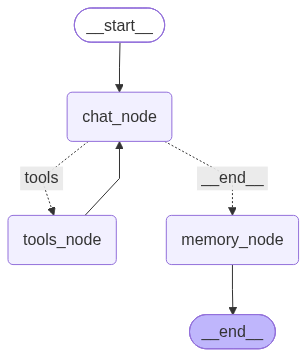

In [12]:
workflow